In [57]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
from datetime import datetime, timezone
from tavily import TavilyClient
from pydantic import BaseModel
from typing import Optional
import re

class StockNewsItem(BaseModel):
    id: int
    ticker: str
    company_name: str
    title: str
    content: str
    raw_content: str
    url: str
    published_date: Optional[datetime] = None


tavily_client = TavilyClient();

# Domain preset
DOMAIN_PRESETS = {
    "general": [
        "reuters.com",
        "cnbc.com",
        "finance.yahoo.com",
        "marketwatch.com",
        "bloomberg.com",
    ],
    "deep_analysis": [
        "seekingalpha.com",
        "barrons.com",
        "wsj.com",
        "morningstar.com",
        "ft.com",
    ],
    "realtime": [
        "cnbc.com",
        "benzinga.com",
        "finance.yahoo.com",
        "marketwatch.com",
        "thestreet.com",
    ],
    "mix_and_match":[
        "bloomberg.com",
        "reuters.com",
        "wsj.com",
        "ft.com",
        "cnbc.com",
        "finance.yahoo.com"
    ],
    "best_free_domains" :[
    "finance.yahoo.com",   
    "reuters.com",         
    "cnbc.com",            
    "marketwatch.com",     
    "benzinga.com",        
    ]
}


def parse_published_date(date_str: Optional[str]) -> Optional[datetime]:
    """Convert string datatime to datetime"""
    if not date_str:
        return None
    
    formats = [
        "%Y-%m-%dT%H:%M:%SZ",       # 2025-01-15T10:30:00Z
        "%Y-%m-%dT%H:%M:%S%z",      # 2025-01-15T10:30:00+00:00
        "%Y-%m-%d %H:%M:%S",        # 2025-01-15 10:30:00
        "%Y-%m-%d",                 # 2025-01-15
        "%a, %d %b %Y %H:%M:%S %z", # Mon, 15 Jan 2025 10:30:00 +0000
        "%a, %d %b %Y %H:%M:%S %Z"  # Tue, 02 Jun 2026 20:07:00 GMT
    ]

    for fmt in formats:
        try:
            dt = datetime.strptime(date_str, fmt)
            if dt.tzinfo is None:
                dt = dt.replace(tzinfo=timezone.utc)
            return dt
        except ValueError:
            continue
    
    #None of format is succeded
    return None

def is_relavant_news(ticker: str, company_name: str, title: str, content: str) -> bool:
    text = f"{title} {content}".lower()
    ticker_lower = ticker.lower()
    company_name_lower = company_name.lower()
    
    # ticker matching
    ticker_pattern = r'\b' + re.escape(ticker_lower) + r'\b'
    has_ticker = bool(re.search(ticker_pattern, text))

    if has_ticker:
        return True
    
    # comany_name matching
    has_company = company_name_lower in text

    if has_company:
        return True
    
    # company alias matching
    index = company_name_lower.replace('.','').replace(',','').find(' ')
    if index != -1:
        company_alias = company_name_lower[:index]
    else:
        company_alias = company_name_lower
    
    has_company_alias = company_alias in text
    if has_company_alias:
        return True
    
    return False

def search_stock_news(ticker: str, company_name: str, max_results: int) -> list[StockNewsItem]:
    """return the most recent news limited by number"""
    
    domains = DOMAIN_PRESETS["best_free_domains"]
    query = f'{company_name} ({ticker}) latest stock news'
    max_news_from_tavily = 10

    response = tavily_client.search(query=query, 
                                    topic="news", 
                                    max_results=max_news_from_tavily,
                                    search_depth="basic",
                                    include_raw_content="markdown",
                                    days = 3,
                                    include_domains=domains)
    
    #-- Filter most relavant top 3 news 
    sorted_results = sorted(
        response.get("results", []),
        key=lambda x: x.get("score", 0),
        reverse=True)
    
    filtered_news = []
    filtered_set = set()

    for idx, r in enumerate(sorted_results):
        if len(filtered_news) >= max_results:
                break
        
        if is_relavant_news(ticker, company_name, r['title'], r['content']):
            filtered_news.append(
                StockNewsItem(
                id = idx,
                ticker=ticker,
                company_name=company_name,
                title=r['title'],
                content=r['content'],
                raw_content=r['raw_content'],
                url=r['url'],
                published_date=parse_published_date(r['published_date'])              
                )
            )
            filtered_set.add(idx)
    
    if len(filtered_news) < max_results:
        sorted_results = [r for i, r in enumerate(sorted_results) if i not in filtered_set]
        id = len(filtered_news)
        for idx, r in enumerate(sorted_results):
            if len(filtered_news) >= max_results:
                break

            filtered_news.append(
                StockNewsItem(
                id = idx + id,
                ticker=ticker,
                company_name=company_name,
                title=r['title'],
                content=r['content'],
                raw_content=r['raw_content'],
                url=r['url'],
                published_date=parse_published_date(r['published_date'])              
                )
            )   
   
    return filtered_news



In [59]:
from langgraph.graph.message import add_messages
from datetime import datetime

class NewsItems(BaseModel):
    id: int
    title: str
    content: str
    content_kr: str    
    raw_content: str
    summary: str
    summary_kr: str
    published_date: Optional[datetime]
    url: str
    sentiment_label: str
    sentiment_score: float


def merge_news_items(existing: list[NewsItems], new: list) -> list[NewsItems]:
    """Merge new news items into existing list, updating fields if item id already exists."""
    existing_map = {item.id: item for item in existing}
    
    for new_item in new:
        new_dict = new_item.model_dump()

        if new_dict.get('id') in existing_map:            
            existing_map[new_dict['id']] = existing_map[new_dict['id']].model_copy(
                update={k: v for k, v in new_dict.items() if v is not None}
            )
        else:
            existing_map[new_dict['id']] = NewsItems(**new_dict)
    
    return list(existing_map.values())

In [60]:
#define GraphState
from typing import Optional, Annotated
from pydantic import BaseModel, Field

class StockNewsState(BaseModel):
    ticker: str = Field(description="Ticker symbol. e.g. SNDK, APPL")
    company_name: Optional[str] = Field(default=None, description="The company name from the ticker symbol. e.g. Apple, inc.")
    sector: Optional[str] = Field(default=None, description="The broad economic sector the company belongs to. e.g. Technology, Healthcare, Financials, Energy")
    industry: Optional[str] = Field(default=None, description="The specific industry within the sector. e.g. Semiconductors, Software, Biotechnology, Oil & Gas")
    news_items: Annotated[Optional[list[NewsItems]], merge_news_items] = Field(default_factory=list)

In [61]:
from app.utils.financial import get_company_info

def route_messages(state: StockNewsState):
    """if there are news items in the state go to END; otherwise, go grab news!"""
    if(state.news_items):
        return 'end'
    return 'search_news'


def search_news(state: StockNewsState):
    """Search Top 3 news"""
    company_info = get_company_info(state.ticker)
    stock_news = search_stock_news(state.ticker, company_info['company_name'], 3)

    news_items = [NewsItems(
            id=idx,
            title=n.title,
            content=n.content,
            content_kr='',
            raw_content=n.raw_content,
            summary='',
            summary_kr='',
            published_date=n.published_date,
            url=n.url,
            sentiment_label='',
            sentiment_score=0.0
            ) for idx, n in enumerate(stock_news)]                  
    
    return {"company_name": company_info['company_name'], 
            "sector": company_info['sector'], 
            "industry": company_info['industry'], 
            "news_items":news_items}




In [62]:
import logging
from data.client import supabase

logger = logging.getLogger(__name__)

def save_to_db(state: StockNewsState):
    """
    persists ticker info and news items to Supabase.
    
    Steps:
        1. Upsert ticker into `tickers` (insert if not exists, skip if already there).
        2. Insert each NewsItem into `stock_news`.
    
    Returns:
        Unchanged state (pass-through node).
    """
    symbol = state.ticker.upper()

    existing = (
        supabase.table("tickers")
        .select("id, company_name, sector, industry")
        .eq("symbol", symbol)
        .maybe_single()
        .execute()
    )

    ticker_id = None

    # Insert
    if existing is None:
        result = (
            supabase.table("tickers")
            .insert({
                "symbol":   symbol,
                "company_name": state.company_name,
                "sector":   state.sector,
                "industry": state.industry    
            })
            .select("id")
            .execute()
        )

        print("result:", result)

        ticker_id = result.data[0]["id"]
        logger.info(f"Inserted new ticker '{symbol}' -> id={ticker_id}")
    else: #Update
        ticker_id = existing.data["id"]
        changes = {}

        if state.company_name != existing.data["company_name"]:
            changes["company_name"] = state.company_name
        if state.sector != existing.data["sector"]:
            changes["sector"] = state.sector
        if state.industry != existing.data["industry"]:
            changes["industry"] = state.industry
        
        if changes:
            supabase.table("tickers").update(changes).eq("id", ticker_id).execute()
            logger.info(f"Updated ticker '{symbol}' -> {changes}")


    # Insert News
    if not state.news_items:
        return state
    
    rows = []
    for item in state.news_items:
        rows.append({
            "ticker_id":    ticker_id,
            "title":        item.title,
            "content":      item.content,
            "content_kr":   item.content_kr,
            "raw_content":  item.raw_content,
            "source_url":          item.url,
            "published_at": item.published_date.isoformat() if item.published_date else None,
            "summary":      item.summary,
            "summary_kr":   item.summary_kr,
            "sentiment":    item.sentiment_label.lower(),
            "sentiment_score": item.sentiment_score
        })
    
    if not rows:
        return state
    
    news_result = (
        supabase.table("stock_news")
        .insert(rows)
        .select("id")
        .execute()
    )

    logger.info(f"Inserted {len(news_result.data)} news item(s) for ticker '{state.ticker}'")
    
    return state

In [63]:
from datetime import datetime
from zoneinfo import ZoneInfo

def load_news(state: StockNewsState):
    """Load news from data base if news exist; fill the state"""   

    pacific = ZoneInfo("America/Los_Angeles")

    now_pacific = datetime.now(pacific)
    start_of_day = now_pacific.replace(hour=0, minute=0, second=0, microsecond=0)
    end_of_day = now_pacific.replace(hour=23, minute=59, second=59, microsecond=999999)

    start_utc = start_of_day.astimezone(ZoneInfo("UTC")).isoformat()
    end_utc = end_of_day.astimezone(ZoneInfo("UTC")).isoformat()

    result = (
        supabase.table("stock_news")
        .select("*, tickers!inner(symbol, is_active)")
        .eq("tickers.symbol", state.ticker.upper())
        .eq("tickers.is_active", True)
        .gte("created_at", start_utc)
        .lte("created_at", end_utc)        
        .order("published_at", desc=True)
        .execute()
    )
    
    if not result or not result.data:
        return state

    news_items = [
        NewsItems(
            id= idx+1,
            title= row["title"],
            content= row["content"],
            content_kr = row["content_kr"],
            raw_content= row["raw_content"],
            published_date= datetime.fromisoformat(row["published_at"]) if row["published_at"] else None,
            summary=        row["summary"],
            summary_kr=     row["summary_kr"],
            sentiment_label=row["sentiment"],
            url=            row["source_url"],
            sentiment_score=row["sentiment_score"]
        )
        for idx, row in enumerate(result.data)
    ]

    return {"news_items": news_items}

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from app.utils.llm_models import get_ollama_llm
from pydantic import BaseModel, Field
from typing import List, Literal

# Model output schema
class NewAnalysis(BaseModel):
    id: int = Field(description="the article id")
    title: str = Field(description="A title of the article")
    content_kr: str = Field(description="A concise Korean translation of the content")
    summary: str = Field(description="A concise summary of the article in 2-3 sentences (English)")
    summary_kr: str = Field(description="Korean translation of the summary")    
    sentiment_label: Literal["Positive", "Negative", "Neutral"] = Field(description="Sentiment analysis result - must of one of: 'Positive', 'Negative', 'Neutral'")
    sentiment_score: float = Field(description="Sentiment confidence score between -1.0 (most negative) and 1.0 (most positive)")

class NewsAnalysisList(BaseModel):
    articles: List[NewAnalysis]


def summarize_news(state: StockNewsState):
    """Summarize 3 news and add sentiment and embedding"""


    news_content = "\n\n".join([f"Article {n.id}: \nTitle: {n.title}\nContent: {n.raw_content}\nURL:{n.url}\nDate: {n.published_date}"
                                for n in state.news_items
                                ]).replace("{","{{").replace("}","}}")  
    
    prompt = f"""
    You are a financial news analyst. Analyze the following news articles about {state.ticker} ({state.company_name})

    For each article, provide:

    1. **id**: the article id
    2. **title**: A title of the article
    3. **content_kr**: A concise Korean translation of the content
    4. **summary**: A concise summary of the article in 4-5 sentences (English)
    5. **summary_kr**: Korean translation of the summary    
    6. **sentiment_label**: Sentiment analysis result - must of one of: 'Positive', 'Negative', 'Neutral'
    7. **sentiment_score**: Sentiment confidence score between -1.0 (most negative) and 1.0 (most positive)

    News Articles:
    {news_content}   

    Return a JSON object with an "articles" key containing the list of results.
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "You are a financial news analyst specializing in stock market analysis."),
        ("user", prompt)
    ])

      
    llm = get_ollama_llm()
    llm_with_structure = llm.with_structured_output(NewsAnalysisList)

    chain = prompt_template | llm_with_structure

    response = chain.invoke({
        "ticker": state.ticker,
        "company_name": state.company_name,
        "news_content": news_content
    })
   
    return {"news_items": response.articles}


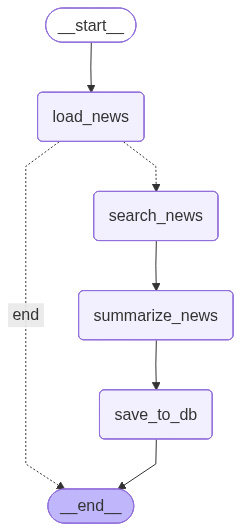

In [65]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder = StateGraph(StockNewsState)
builder.add_node("load_news", load_news)
#builder.add_node("route_messages", route_messages)
builder.add_node("search_news", search_news)
builder.add_node("summarize_news", summarize_news)
builder.add_node("save_to_db", save_to_db)

builder.add_edge(START, "load_news")
#builder.add_edge("load_news","route_messages")
#builder.add_conditional_edges("route_messages", route_messages, {"search_news": "search_news", "end": END})
builder.add_conditional_edges("load_news",route_messages,{"search_news": "search_news", "end":END})
builder.add_edge("search_news","summarize_news")
builder.add_edge("summarize_news", "save_to_db")
builder.add_edge("save_to_db", END)

stock_news_graph = builder.compile()

display(Image(stock_news_graph.get_graph(xray=1).draw_mermaid_png()))


In [ ]:
result= stock_news_graph.invoke({"ticker": "RKLB", "company_name": "", "sector":None, "industry": None})

In [67]:
import pytz
from datetime import datetime, timezone

def to_pst(date_to_convert:Optional[datetime]) -> str:
    if not date_to_convert:
        return None
        
    PST = pytz.timezone("America/Los_Angeles")
    return date_to_convert.astimezone(PST).strftime("%a, %d %b %Y %H:%M:%S %Z")


from IPython.display import Markdown, display

def render_stock_news(state: StockNewsState):
    md = f"# 📈 {state['ticker']} - {state['company_name']} News\n"
    md += f"**Sector**: {state['sector']}  \n"
    md += f"**Industry**:{state['industry']}\n\n"
    
    for i, item in enumerate(state['news_items'], 1):
        
        emoji = {"Positive": "🟢", "Negative": "🔴", "Neutral": "🟡"}.get(item.sentiment_label, "⚪")
        
        md += f"## {i}. {item.title}\n\n"
        md += f"**Published date**: {to_pst(item.published_date)}  \n"
        md += f"**Sentiment**: {emoji} {item.sentiment_label} (score: {item.sentiment_score:.2f})  \n"
        md += f"**URL**: [{item.url}]({item.url})\n\n"
        md += f"### Summary\n{item.summary}\n\n"
        md += f"### Summary in Korean\n{item.summary_kr}\n\n"        
        md += f"### content\n{item.content.replace('#',r'\#')}\n\n"
        md += f"### content in Korean\n{item.content_kr.replace('#',r'\#')}\n\n"
        md += "-------------------------------------------------------------\n\n"
    
    display(Markdown(md))

In [68]:
render_stock_news(result)

# 📈 SNDK - Sandisk Corporation News
**Sector**: Technology  
**Industry**:Computer Hardware

## 1. Here are Wednesday's biggest analyst calls: Nvidia, Apple, Micron, SanDisk, IBM, Viking, Yum, Meta & more

**Published date**: Wed, 03 Jun 2026 05:21:37 PDT  
**Sentiment**: 🟢 Positive (score: 0.65)  
**URL**: [https://www.cnbc.com/2026/06/03/big-wall-street-analyst-calls-from-stocks-like-nvidia.html](https://www.cnbc.com/2026/06/03/big-wall-street-analyst-calls-from-stocks-like-nvidia.html)

### Summary
This CNBC article summarizes major Wall Street analyst calls for Wednesday, highlighting mixed signals across various sectors including technology and consumer goods. Morgan Stanley reiterated an overweight rating on Micron and SanDisk while raising their price targets significantly to $1,050 and $1,750 respectively, citing strong memory stock performance in 2026. Other notable moves include upgrades for Yum Brands and downgrades for Chipotle and Shake Shack due to visibility concerns. The article also mentions positive outlooks for IBM driven by AI/Quantum shifts and Meta's revenue upside potential.

### Summary in Korean
이 CNBC 기사는 금요일 월스트리트의 주요 분석가 의견을 요약하며, 기술 및 소비자 제품 등 다양한 분야에서 혼합된 신호를 강조합니다. 모건 스탠리는 2026 년 메모리 주식의 강력한 성과로 인해 마이크론과 샌디스크에 대해 중량주로 재확인하고 목표 주가를 각각 $1,050 과 $1,750 로 크게 인상했습니다. 다른 주목할 만한 움직임으로는 유먼 브랜드가 상향 조정된 반면 치폴레와 쉐이크 Shack 는 가시성 부족으로 하향 조정되었습니다. 또한 IBM 은 AI/양자 전환에 대한 긍정적 전망과 메타의 수익 상승 잠재력으로 인해 매수 의견을 유지하는 등 다양한 기업들의 분석가 의견이 소개됩니다.

### content
\# Here are Wednesday's biggest analyst calls: Nvidia, Apple, Micron, SanDisk, IBM, Viking, Yum, Meta & more. Here are Wednesday's biggest calls on Wall Street: KeyBanc initiates DigitalOcean as overweight KeyBanc said the company's playbook has "room to expand." "We are initiating coverage of DigitalOcean with an Overweight rating and a $200 price target." Goldman Sachs initiates Omnicom as buy Goldman said the advertising company is well positioned for growth. "At the keynote, we expect Apple to announce the new AI-enhanced Siri, which will include many of the delayed features from the 2024 WWDC (e.g., on-screen awareness, personal context), as well as a dedicated Siri app that will have a chat interface similar to other LLMs." Morgan Stanley upgrades Yum Brands to overweight from equal weight and downgrades Chipotle to equal weight from overweight Morgan Stanley said Yum Brands is undervalued.

### content in Korean
[CNBC 보도] 월스트리트의 주요 분석가 의견 중 금요일 가장 큰 것들입니다. KeyBanc 는 DigitalOcean 을 '중량주'로 시작했으며, Omnicom 은 골드만삭스가 매수 의견을 내렸고 SSR Mining 은 RBC 가 업계를 초과할 것으로 예상했습니다. 애플은 WWDC 전에 AI 강화된 Siri 를 발표할 것이라는 기대감으로 매수가 유지되었습니다. 유먼 브랜드는 모건 스탠리가 중량주로 상향 조정했으나 치폴레와 쉐이크 Shack 는 하향 조정되었습니다. AT&T, 빅토리아 시크릿 등도 하향 조정을 받았습니다. 반면 IBM 은 시티그룹이 목표 주가를 375 달러로 인상하며 매수 의견을 유지했습니다.

-------------------------------------------------------------

## 2. MU, SNDK, WDC: Memory Stocks Dip As Broadcom’s Forecast Dampens AI Sentiment, Retail Turns Buyer - Yahoo Finance

**Published date**: Thu, 04 Jun 2026 19:42:00 PDT  
**Sentiment**: 🟡 Neutral (score: 0.15)  
**URL**: [https://finance.yahoo.com/markets/stocks/articles/mu-sndk-wdc-memory-stocks-024254770.html](https://finance.yahoo.com/markets/stocks/articles/mu-sndk-wdc-memory-stocks-024254770.html)

### Summary
This Yahoo Finance article reports on a significant dip in memory stocks like Micron and SanDisk following Broadcom's disappointing AI revenue forecast for the third quarter. Although Broadcom beat earnings expectations, its guidance fell short of analyst estimates, triggering a broader selloff across the semiconductor sector including AVGO, MU, SNDK, and WDC. Despite the decline, retail investors are viewing this as a buying opportunity to accumulate positions in memory stocks that have been major beneficiaries of the AI boom.

### Summary in Korean
야후 파이낸스 기사는 브로드컴의 3 분기 예상치 못한 AI 매출 전망으로 인해 마이크론과 샌디스크 같은 메모리 주식들이 크게 하락했다고 보도합니다. 브로드컴은 실적에서는 기대를 초과했지만, 가이드라인이 분석가들의 예측에 미치지 못해 반도체 섹터를 포함한 광범위한 매도세가 발생했습니다. 그럼에도 불구하고 소매 투자자들은 AI 붐의 주요 수혜자인 메모리 주식을 축적할 기회로 이 하락을 보고 있습니다.

### content
\# MU, SNDK, WDC: Memory Stocks Dip As Broadcom’s Forecast Dampens AI Sentiment, Retail Turns Buyer. * Broadcom projected $16 billion in AI chip revenue in the third quarter, much below estimates of $17.2 billion, and kept its fiscal year 2027 outlook unchanged at $100 billion. * Investors viewed Broadcom’s forecasts as a bearish signal, and retail investors appeared to be using the dip in memory stock to increase their positions. Micron Technology Inc. led declines in memory and chip stocks on Thursday as investors hit pause on the AI trade after many viewed Broadcom’s latest forecasts as a sign of lingering softness in parts of the chip market. Micron shares fell 7.7% on Thursday, their worst fall in over a month, and declined nearly 5% in the overnight session. The Broadcom-triggered dip in memory stocks came as an opportunity to add positions in the segment that has emerged as the biggest beneficiary of the AI boom, according to retail investors.

### content in Korean
[야후 파이낸스 보도] 브로드컴의 예상치 못한 AI 칩 매출 전망이 시장 심리를 약화시키면서 메모리 주식인 마이크론 (MU), 샌디스크 (SNDK), 웨스턴 디지털 (WDC) 이 하락했습니다. 브로드컴은 3 분기 AI 칩 매출을 $160 억으로 예측했으나 예상치 $172 억에 미치지 못해 주가가 급락했습니다. 이에 따라 반도체 ETF 와 나스닥 지수도 동반 하락했지만, 소매 투자자들은 이러한 조정 기회를 이용해 매수에 나섰다. 일부 트레이더들은 단기 조정을 '건강한 후퇴'로 보며 장기적인 상승세를 믿고 있습니다.

-------------------------------------------------------------

## 3. Micron Drops 7% as Broadcom’s Disappointing AI Outlook Triggers a Semiconductor Selloff - Yahoo Finance

**Published date**: Thu, 04 Jun 2026 08:15:44 PDT  
**Sentiment**: 🔴 Negative (score: -0.45)  
**URL**: [https://finance.yahoo.com/markets/stocks/articles/micron-drops-7-broadcom-disappointing-151544845.html](https://finance.yahoo.com/markets/stocks/articles/micron-drops-7-broadcom-disappointing-151544845.html)

### Summary
This article details how Micron's stock dropped 7% due to sympathy selling triggered by Broadcom's lower-than-expected AI chip guidance for the third quarter. While Broadcom beat on headline numbers and revenue grew significantly, its forward guidance missed estimates, causing a reset in sentiment across memory stocks like SanDisk and Western Digital as well.

### Summary in Korean
이 기사는 브로드컴의 3 분기 예상치 못한 낮은 AI 칩 가이드라인으로 인해 마이크론 주가가 연대기적 매도세로 7% 하락했다고 설명합니다. 브로드컴은 실적과 매출에서 기대를 초과했지만, 향후 전망이 예측에 미치지 못해 메모리 주식인 샌디스크와 웨스턴 디지털을 포함한 전체 섹터의 심리가 재설정되었습니다.

### content
* Broadcom's Q3 AI chip guidance of $16 billion missed the $17.2 billion estimate, sending AVGO down 14% and dragging MU down 7% in sympathy. * SanDisk fell 3% and Western Digital dropped 2% as Broadcom's underwhelming AI outlook spread contagion across the broader memory chip complex. * The analyst who called NVIDIA in 2010 just named his top 10 stocks and Broadcom wasn't one of them. Shares of **Micron Technology** (NASDAQ:MU) are down by about 7% to $1,004 in mid-morning trading on Thursday, June 4, after **Broadcom** (NASDAQ:AVGO) delivered an AI chip outlook that markets viewed as underwhelming. Broadcom CEO Hock Tan stated, "The momentum continues and in Q3 we expect semiconductor revenue from AI to grow over 200 percent year-over-year to $16.0 billion." The figure was strong, yet it sat below whisper expectations for hyperscaler AI orders, and that's the gap that traders are punishing. As a key supplier of high-bandwidth memory (HBM) for AI accelerators, MU stock trades in lockstep with AI capex sentiment, and Broadcom's softer-than-hoped guide reset the bar for the entire complex.

### content in Korean
[야후 파이낸스 보도] 브로드컴의 실망스러운 AI 전망이 반도체 매도세를 촉발하며 마이크론 주가가 7% 하락했습니다. 브로드컴은 3 분기 AI 칩 매출을 $160 억으로 예상했으나 분석가들의 $172 억 예측에 미치지 못해 심리가 약화되었습니다. 이에 따라 샌디스크와 웨스턴 디지털도 동반 하락했지만, 마이크론의 기본적 상황이나 HBM 주문량은 여전히 견고합니다.

-------------------------------------------------------------

